# Faizaan Ali | HW6 | Task 1

## MDP Problem Setup

In [ ]:
import numpy as np

# Grid size
GRID_SIZE = 10

# States: (row, col)
states = [(i, j) for i in range(GRID_SIZE) for j in range(GRID_SIZE)]

# Actions
actions = ["up", "down", "left", "right"]

terminal_states = [(0, 0), (9, 9)]

# Step reward
def step_reward(state):
    return -1

# for reward design based experiment later on
def reward_design1(state):
    if state == (0, 0):
        return 2   # smaller, closer
    elif state == (9, 9):
        return 10  # larger, farther
    return step_reward(state)

def reward_design2(state):
    if state == (0, 0):
        return 10  # now closer reward is bigger
    elif state == (9, 9):
        return 2   # farther reward smaller
    return step_reward(state)

## Environment Setup

We consider a 10×10 grid world where each state corresponds to a position (i, j) on the grid. The agent can take one of four actions at each state: up, down, left, or right, with deterministic transitions. Two terminal states are defined at (0,0) and (9,9). At each step, the agent receives a reward of −1 to encourage shorter paths. To study the effect of reward design, we define two reward functions: in the first, the distant terminal state (9,9) provides a larger reward than the closer state (0,0), while in the second, the reward values are reversed. This setup allows us to analyze how changing reward structures influences the learned policy.

## Transistion Function

In [ ]:
def next_state(state, action):
    if state in terminal_states:
        return state

    i, j = state

    if action == "up":
        i = max(i - 1, 0)
    elif action == "down":
        i = min(i + 1, GRID_SIZE - 1)
    elif action == "left":
        j = max(j - 1, 0)
    elif action == "right":
        j = min(j + 1, GRID_SIZE - 1)

    return (i, j)

Function for mapping actions to matrix movements.

## Value Iteration

In [ ]:
# Initialize value function: terminal states set to their reward
V = {s: reward_design1(s) if s in terminal_states else 0 for s in states}

theta = 1e-4  # convergence threshold
gamma = 0.9   # discount factor

while True:
    delta = 0
    new_V = V.copy()

    for s in states:
        if s in terminal_states:
            continue  # terminal states keep their reward

        # Compute value for all actions
        values = []
        for a in actions:
            ns = next_state(s, a)
            r = reward_design1(ns)  # reward of next state
            values.append(r + gamma * V[ns])

        # Update value function
        best_value = max(values)
        delta = max(delta, abs(best_value - V[s]))
        new_V[s] = best_value

    V = new_V
    if delta < theta:
        break

print("Value iteration converged!")

Value iteration converged!


We use value iteration to compute the optimal value function and policy for the grid world. The value function is initialized to zero for all states and iteratively updated using the Bellman optimality equation. At each step, the algorithm evaluates all possible actions from a state and selects the one that maximizes the expected return, defined as the immediate reward of the next state plus the discounted value of that state. The discount factor γ (gamma) controls how much the agent values future rewards relative to immediate rewards, with higher values placing more emphasis on long-term outcomes. The iteration continues until convergence, which is determined by a threshold parameter θ (theta). Specifically, θ defines the minimum change in the value function between iterations; once the maximum update across all states falls below θ, the algorithm terminates. After convergence, the optimal policy is extracted by choosing, for each state, the action that yields the highest expected value according to the learned value function.

## Extract Policy

In [ ]:
# Derive policy from value function
policy = {}

for s in states:
    if s in terminal_states:
        policy[s] = "T"
        continue

    best_action = None
    best_value = float("-inf")

    for a in actions:
        ns = next_state(s, a)
        val = reward_design1(ns) + gamma * V[ns]  # reward of next state

        if val > best_value:
            best_value = val
            best_action = a

    policy[s] = best_action

After computing the value function, we derive the optimal policy by selecting the best action for each state. For every non-terminal state, we evaluate all possible actions and compute their expected value using the reward and the discounted value of the next state. The action that yields the highest value is chosen as the optimal action for that state. Terminal states are assigned a special label (“T”) since no further actions are taken from them.

## Display Value Function

In [ ]:
print("Value Function:\n")

for i in range(GRID_SIZE):
    row = []
    for j in range(GRID_SIZE):
        row.append(f"{V[(i,j)]:6.2f}")
    print(" ".join(row))

Value Function:

  2.00   3.80   2.42   1.18   0.06  -0.95  -0.90   0.11   1.24   2.48
  3.80   2.42   1.18   0.06  -0.95  -0.90   0.11   1.24   2.48   3.87
  2.42   1.18   0.06  -0.95  -0.90   0.11   1.24   2.48   3.87   5.41
  1.18   0.06  -0.95  -0.90   0.11   1.24   2.48   3.87   5.41   7.12
  0.06  -0.95  -0.90   0.11   1.24   2.48   3.87   5.41   7.12   9.03
 -0.95  -0.90   0.11   1.24   2.48   3.87   5.41   7.12   9.03  11.14
 -0.90   0.11   1.24   2.48   3.87   5.41   7.12   9.03  11.14  13.49
  0.11   1.24   2.48   3.87   5.41   7.12   9.03  11.14  13.49  16.10
  1.24   2.48   3.87   5.41   7.12   9.03  11.14  13.49  16.10  19.00
  2.48   3.87   5.41   7.12   9.03  11.14  13.49  16.10  19.00  10.00


## Display Policy

In [ ]:
def print_policy(policy, grid_size):
    arrow_map = {
        "up": "↑",
        "down": "↓",
        "left": "←",
        "right": "→",
        "T": "T"
    }

    print("\nPolicy:\n")
    for i in range(grid_size):
        row = [arrow_map[policy[(i, j)]] for j in range(grid_size)]
        print(" ".join(row))

print_policy(policy, GRID_SIZE)


Policy:

T ← ← ← ← ← ↓ ↓ ↓ ↓
↑ ↑ ↑ ↑ ↑ ↓ ↓ ↓ ↓ ↓
↑ ↑ ↑ ↑ ↓ ↓ ↓ ↓ ↓ ↓
↑ ↑ ↑ ↓ ↓ ↓ ↓ ↓ ↓ ↓
↑ ↑ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
↑ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
→ → → → → → → → → T


This above output shows the optimal move for a given cell based on the Value Iteration results.

## Experiment

In the following experiment, we change the reward design by swapping the goal state rewards (see first cell).

Essentially, we swap the low/high rewards of the corner cells and observe how the policy changes.

Reward Design 1: (0,0) - 2, (9,9) - 10

Policy:

T ← ← ← ← ← ← ↓ ↓ ↓
↑ ↑ ↑ ↑ ↑ ↑ ↓ ↓ ↓ ↓
↑ ↑ ↑ ↑ ↑ ↓ ↓ ↓ ↓ ↓
↑ ↑ ↑ ↑ ↓ ↓ ↓ ↓ ↓ ↓
↑ ↑ ↑ ↓ ↓ ↓ ↓ ↓ ↓ ↓
↑ ↑ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
↑ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓
→ → → → → → → → → T



Reward Design 2: (0,0) - 10, (9,9) - 2

Policy:

T ← ← ← ← ← ← ← ← ←
↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑
↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑
↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↓
↑ ↑ ↑ ↑ ↑ ↑ ↑ ↑ ↓ ↓
↑ ↑ ↑ ↑ ↑ ↑ ↑ ↓ ↓ ↓
↑ ↑ ↑ ↑ ↑ ↑ ↓ ↓ ↓ ↓
↑ ↑ ↑ ↑ ↑ ↓ ↓ ↓ ↓ ↓
↑ ↑ ↑ ↑ ↓ ↓ ↓ ↓ ↓ ↓
↑ ↑ ↑ → → → → → → T
Number of states with different actions: 44
Example differing states: [(0, 7), (0, 8), (0, 9), (1, 6), (1, 7), (1, 8), (1, 9), (2, 5), (2, 6), (2, 7)]


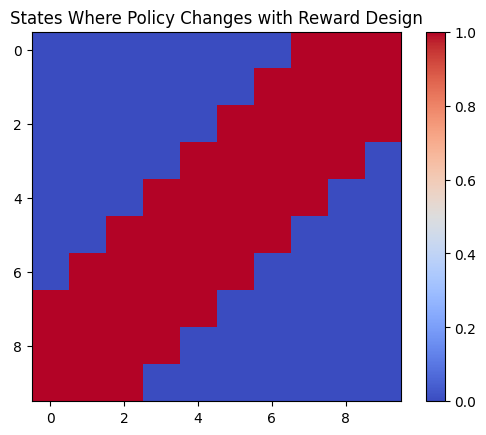

In [ ]:
def value_iteration(reward_func, gamma=0.9, theta=1e-4):
    V = np.zeros((GRID_SIZE, GRID_SIZE))
    policy = np.empty((GRID_SIZE, GRID_SIZE), dtype=object)

    while True:
        delta = 0
        for s in states:
            if s in terminal_states:
                continue
            v = V[s]
            values = []
            for a in actions:
                next_s = next_state(s, a)
                values.append(reward_func(next_s) + gamma * V[next_s])
            V[s] = max(values)
            delta = max(delta, abs(v - V[s]))
        if delta < theta:
            break

    # extract policy
    for s in states:
        if s in terminal_states:
            policy[s] = 'T'
            continue
        q_values = {}
        for a in actions:
            next_s = next_state(s, a)
            q_values[a] = reward_func(next_s) + gamma * V[next_s]
        policy[s] = max(q_values, key=q_values.get)

    return V, policy


V1, policy1 = value_iteration(reward_design1)
V2, policy2 = value_iteration(reward_design2)

print("Reward Design 1: (0,0) - 2, (9,9) - 10")
print_policy(policy=policy1, grid_size=GRID_SIZE)
print("\n\n")
print("Reward Design 2: (0,0) - 10, (9,9) - 2")
print_policy(policy=policy2, grid_size=GRID_SIZE)

diff_states = [s for s in states if policy1[s] != policy2[s]]
print("Number of states with different actions:", len(diff_states))
print("Example differing states:", diff_states[:10])

import matplotlib.pyplot as plt

grid = np.zeros((GRID_SIZE, GRID_SIZE))
for (i,j) in states:
    if policy1[(i,j)] != policy2[(i,j)]:
        grid[i,j] = 1

plt.imshow(grid, cmap="coolwarm")
plt.title("States Where Policy Changes with Reward Design")
plt.colorbar()
plt.show()

## Discussion

### Why this is an MDP
This setup satisfies the Markov Decision Process (MDP) properties:
- States: Grid positions (i, j) in a 10×10 grid
- Actions: Up, down, left, right
- Transition function: Deterministic movement in the grid
- Rewards: State-dependent rewards based on the reward design (including step cost and terminal rewards)
- Markov property: The next state depends only on the current state and action, not on past history

### What the learned policy is doing
The learned policy directs the agent toward one of the terminal states while balancing:
- Distance (step cost = −1 per move)
- Terminal reward magnitude

In Reward Design 1:
- The agent prefers the farther but higher reward state at (9,9)
- The policy largely directs movement toward the bottom-right of the grid

In Reward Design 2:
- The reward structure is reversed, making (0,0) more attractive
- The policy shifts to favor movement toward the top-left

### Experiment Analysis
Changing the reward structure alters the learned policy.

- In Design 1: Agent prioritizes larger long-term reward (10 at (9,9))
- In Design 2: Agent prioritizes closer, higher immediate reward (10 at (0,0))

This results in 44 states with different actions between the two policies, showing a substantial shift in behavior.

This experiment demonstrates that:
- The reward function directly shapes agent behavior
- Even with identical dynamics and discount factor, different reward designs lead to different optimal policies
- The agent effectively learns to balance path cost vs reward magnitude
